In [1]:
import torch
import torch.nn as nn
from torch.optim import AdamW,Adam
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import pickle
import matplotlib.pyplot as plt

In [2]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
df = pd.read_csv("Climate_data.csv")

data = df.drop("Date Time" , axis=1)
column_label = data.columns.tolist()
data = torch.tensor(data.values , dtype=torch.float32)

mean = data.mean(dim=0)
std = data.std(dim=0)

data = (data - mean)/std

In [4]:
data = data[:len(data)-(len(data)%6)]
data = data.float().reshape(6,data.shape[0]//6,*data.shape[1:]).mean(dim=0)

In [5]:
data_X = []
data_y = []

for i in range(0 , len(data)-(72*10)-12-1):
    data_X.append(data[i:i+(72*10)])
    data_y.append(data[i+(72*10):i+(72*10)+12 , 1])
data_X = torch.stack(data_X)
data_y = torch.stack(data_y)

In [6]:
training_time = int(0.8 * len(data_X))

train_x = data_X[:training_time]
train_y = data_y[:training_time]
test_x = data_X[training_time:]
test_y = data_y[training_time:]

In [7]:
dataset = TensorDataset(train_x , train_y)
loader = DataLoader(dataset , batch_size=100 , shuffle=False)

In [8]:
class Encoder_Layer(nn.Module):
    def __init__(self , hidden_dim , num_heads):
        super().__init__()
        self.hidden_dim = hidden_dim 
        self.num_heads = num_heads
        self.head_dim = hidden_dim//num_heads

        # For Query Key and Values
        self.query = nn.Linear(in_features=hidden_dim , out_features=hidden_dim , bias=False)
        self.key = nn.Linear(in_features=hidden_dim , out_features=hidden_dim , bias=False)
        self.value = nn.Linear(in_features=hidden_dim , out_features=hidden_dim , bias=False)

        # Attention combining all the other attentions
        self.attention = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

        # Layer Normalisation
        self.layer_norm_1 = nn.LayerNorm(hidden_dim)
        self.layer_norm_2 = nn.LayerNorm(hidden_dim)

        # Feed Forward Network ffn
        self.ffn = nn.Sequential(
            nn.Linear(in_features=hidden_dim , out_features=hidden_dim*4),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim*4 , out_features=hidden_dim)
        )


    def forward(self , x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]
        embedding = x

        # Querry , Key and Values
        Q = self.query(embedding)
        K = self.key(embedding)
        V = self.value(embedding)
        Q = Q.reshape(batch_size , seq_len , self.num_heads , self.head_dim).transpose(1,2)
        K = K.reshape(batch_size , seq_len , self.num_heads , self.head_dim).transpose(1,2)
        V = V.reshape(batch_size , seq_len , self.num_heads , self.head_dim).transpose(1,2)
        
        # Total Attention
        score = Q @ K.transpose(-2,-1)
        attention = torch.softmax(score/(self.head_dim**0.5) , dim=-1) @ V        
        attention = attention.transpose(1,2)
        attention = attention.reshape(batch_size , seq_len , self.hidden_dim)
        attention = self.attention(attention)

        # Feed Forward network and layer norm
        embedding = embedding + attention
        embedding = self.layer_norm_1(embedding)
        ffn_out = self.ffn(embedding)
        embedding = embedding + ffn_out
        embedding = self.layer_norm_2(embedding)

        # Returning the contextualised embeddings
        return embedding
    


class Encoder(nn.Module):
    def __init__(self , hidden_dim , num_heads):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        seq_len = 720
        N = 10000
        position = torch.arange(seq_len).unsqueeze(1)      # (720,1)
        i = torch.arange(self.hidden_dim // 2)             # (32,)        
        div_term = N ** (-2 * i / self.hidden_dim)         # (32,)    
        positional_encoding = torch.zeros(seq_len, self.hidden_dim)
        positional_encoding[:, 0::2] = torch.sin(position * div_term)
        positional_encoding[:, 1::2] = torch.cos(position * div_term)
        self.positional_encoding = positional_encoding.to(device)
        
        # Initially Convert the given vector into hidden dimension
        self.initial_embedding = nn.Linear(in_features=14 , out_features=hidden_dim)

        # Encoding layer
        self.layer_1 = Encoder_Layer(hidden_dim , num_heads)
        self.layer_2 = Encoder_Layer(hidden_dim , num_heads)

        # FInal Predictor
        self.final = nn.Linear(in_features=hidden_dim , out_features=12)

    def forward(self , x):
        x = x.to(device)

        # Initial Embedding 
        embedding = self.initial_embedding(x)

        # Positional Encoding
        embedding = embedding + self.positional_encoding

        # Passing through embedding layers
        embedding = self.layer_1(embedding)
        embedding = self.layer_2(embedding)

        # Use last time as it has all the context from previous one also to predict next day weather
        y_pred = self.final(embedding[: , -1 , :])

        return y_pred

In [9]:
torch.manual_seed(12)
Model = Encoder(64 , 2).to(device)
optimiser = Adam(Model.parameters() , lr=1e-4 , weight_decay=1e-3 , )
loss_fn = nn.MSELoss()

epochs = 10
losses = []

for epoch in range(epochs):
    running_loss = 0
    batch = 0
    for x , y in loader:
        batch = batch+1
        y_pred = Model(x)
        loss = loss_fn(y_pred , y.to(device))
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        running_loss = running_loss + loss.item()
        print(f"Epoch : {epoch+1}\tBatch : {batch}/{len(loader)}\tLoss : {loss.item()}")
    losses.append(running_loss/len(loader))
    print(f"----------Epoch : {epoch+1}\tAverage Loss in epoch : {running_loss/len(loader)}----------\n")

Epoch : 1	Batch : 1/555	Loss : 0.7150337100028992
Epoch : 1	Batch : 2/555	Loss : 0.5958441495895386
Epoch : 1	Batch : 3/555	Loss : 0.4014599621295929
Epoch : 1	Batch : 4/555	Loss : 0.38934624195098877
Epoch : 1	Batch : 5/555	Loss : 0.5638208389282227
Epoch : 1	Batch : 6/555	Loss : 0.422005832195282
Epoch : 1	Batch : 7/555	Loss : 0.2803305387496948
Epoch : 1	Batch : 8/555	Loss : 0.26654836535453796
Epoch : 1	Batch : 9/555	Loss : 0.2468390017747879
Epoch : 1	Batch : 10/555	Loss : 0.29116734862327576
Epoch : 1	Batch : 11/555	Loss : 0.25984662771224976
Epoch : 1	Batch : 12/555	Loss : 0.2780211865901947
Epoch : 1	Batch : 13/555	Loss : 0.15856298804283142
Epoch : 1	Batch : 14/555	Loss : 0.1673714965581894
Epoch : 1	Batch : 15/555	Loss : 0.1878339946269989
Epoch : 1	Batch : 16/555	Loss : 0.24663697183132172
Epoch : 1	Batch : 17/555	Loss : 0.14515142142772675
Epoch : 1	Batch : 18/555	Loss : 0.10766126215457916
Epoch : 1	Batch : 19/555	Loss : 0.10881449282169342
Epoch : 1	Batch : 20/555	Loss : 

In [10]:
# Saving model weights
# weights = Model.state_dict()
# with open("Transformer_model_weights.pkl","wb") as F:
#     pickle.dump(weights , F)

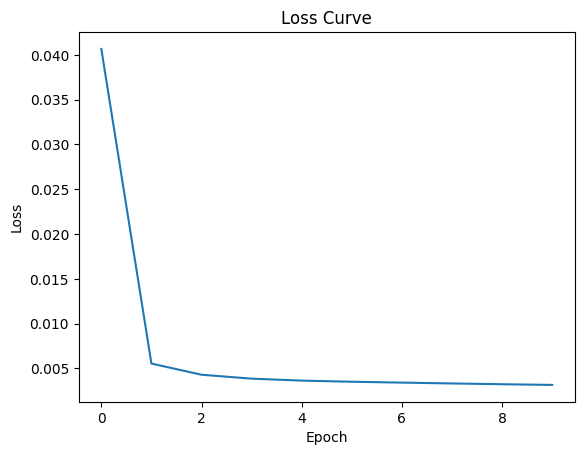

In [11]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

In [12]:
len(test_x)

13872

In [13]:
with torch.no_grad():
    y_pred = Model(test_x[:100])
    y_pred = y_pred.cpu()
    df1 = pd.DataFrame((test_y[:100]*std[1] + mean[1]).numpy())
    df2 = pd.DataFrame((y_pred*std[1] + mean[1]).numpy())
    # df1.columns = column_label
    # df2.columns = column_label
    mse = nn.MSELoss()(y_pred , test_y[:100])
    mae = nn.L1Loss()(y_pred , test_y[:100])
    huber = nn.HuberLoss()(y_pred , test_y[:100])

In [14]:
print(f"MSE Loss : {mse}")
print(f"MAE Loss : {mae}")
print(f"Huber Loss : {huber}")

MSE Loss : 0.005657767876982689
MAE Loss : 0.06478863954544067
Huber Loss : 0.0028288839384913445


In [15]:
(df1-df2).max() - (df1-df2).min()

0     0.529578
1     0.692666
2     0.991343
3     1.153615
4     1.187547
5     1.386229
6     1.421509
7     1.455893
8     1.606033
9     1.695182
10    1.806949
11    1.821432
dtype: float32

In [16]:
df1.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,7.775000,7.635000,7.571666,7.526667,7.425000,7.460000,7.510000,7.451667,7.460000,7.400000,7.271667,7.086666
1,7.635000,7.571666,7.526667,7.425000,7.460000,7.510000,7.451667,7.460000,7.400000,7.271667,7.086666,6.968333
2,7.571666,7.526667,7.425000,7.460000,7.510000,7.451667,7.460000,7.400000,7.271667,7.086666,6.968333,6.918334
3,7.526667,7.425000,7.460000,7.510000,7.451667,7.460000,7.400000,7.271667,7.086666,6.968333,6.918334,6.848333
4,7.425000,7.460000,7.510000,7.451667,7.460000,7.400000,7.271667,7.086666,6.968333,6.918334,6.848333,6.801667


In [17]:
df2.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,8.232171,8.216108,8.078708,8.189636,8.191803,8.113906,8.368145,8.226148,8.210184,8.243891,8.179551,8.352379
1,8.159783,8.154005,8.019661,8.112915,8.110790,8.039054,8.298967,8.157762,8.130040,8.166079,8.095581,8.266520
2,7.985923,7.996665,7.866766,7.937684,7.937330,7.872375,8.132059,7.995157,7.959304,7.998974,7.924195,8.086838
3,7.912640,7.920307,7.799064,7.865242,7.869227,7.803495,8.057912,7.915301,7.890112,7.925292,7.850935,8.009508
4,7.849783,7.861373,7.744056,7.802082,7.804861,7.741861,7.993100,7.852466,7.825554,7.860124,7.784926,7.940846


In [18]:
# 1 - Main Query ko hidden dimension ka bana ke reshape kar do faster rahega    --DONE
# 2 - ye ek encoder layer hai jo stack karni hai isiliye alag se me embedding karao intial aur fir isme input daalo
# 3 - Positional encoding bhi sirf ek hi baar judegi so use bhi dusre wale me rakh dena
# 4 - mean pooling try karo dekho kaunsa acha hai